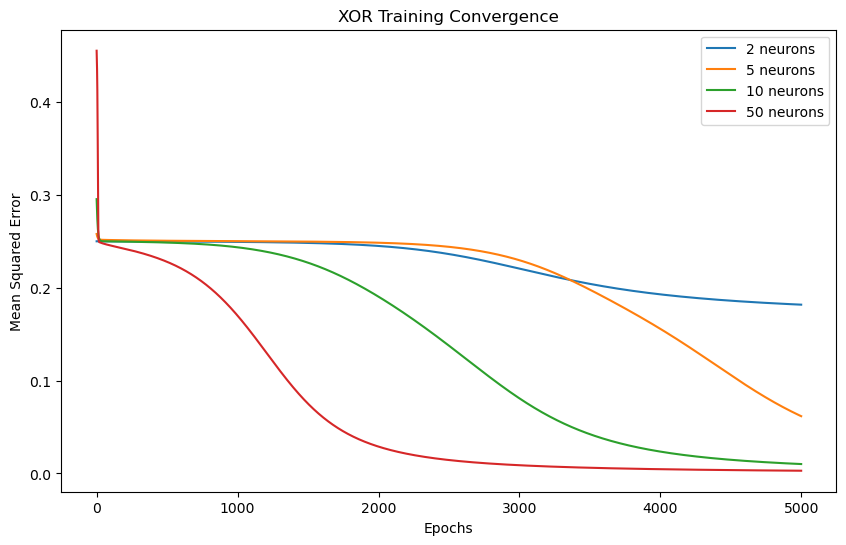

In [8]:
# 1. MLP Implementation for XOR
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

class MLP:
    def __init__(self, hidden_neurons, learning_rate=0.1):
        self.hidden_neurons = hidden_neurons
        self.lr = learning_rate
        
        self.W1 = np.random.uniform(-1, 1, (2, self.hidden_neurons))
        self.b1 = np.zeros((1, self.hidden_neurons))
        self.W2 = np.random.uniform(-1, 1, (self.hidden_neurons, 1))
        self.b2 = np.zeros((1, 1))
        
    def train(self, X, y, epochs=10000):
        loss_history = []
        
        for epoch in range(epochs):
            hidden_output = sigmoid(np.dot(X, self.W1) + self.b1)
            final_output = sigmoid(np.dot(hidden_output, self.W2) + self.b2)
            
            error = y - final_output
            loss = np.mean(error ** 2)
            loss_history.append(loss)
            
            d_output = error * sigmoid_derivative(final_output)
            
            error_hidden = d_output.dot(self.W2.T)
            d_hidden = error_hidden * sigmoid_derivative(hidden_output)
            
            self.W2 += hidden_output.T.dot(d_output) * self.lr
            self.b2 += np.sum(d_output, axis=0, keepdims=True) * self.lr
            self.W1 += X.T.dot(d_hidden) * self.lr
            self.b1 += np.sum(d_hidden, axis=0, keepdims=True) * self.lr
            
        return loss_history

# Dataset
X_xor = np.array([[0,0], [0,1], [1,0], [1,1]])
y_xor = np.array([[0], [1], [1], [0]])

# Training and Plotting
neurons_list = [2, 5, 10, 50]
plt.figure(figsize=(10, 6))

for n in neurons_list:
    mlp = MLP(hidden_neurons=n)
    loss_hist = mlp.train(X_xor, y_xor, epochs=5000)
    plt.plot(loss_hist, label=f'{n} neurons')

plt.title('XOR Training Convergence')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.show()

In [9]:
# 2. IRIS Dataset Preprocessing
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

iris = load_iris()
X_iris = iris.data
y_iris = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X_iris, y_iris, test_size=0.20, random_state=42
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Training data shape:", X_train_scaled.shape)
print("Testing data shape:", X_test_scaled.shape)

Training data shape: (120, 4)
Testing data shape: (30, 4)


In [10]:
# 3. Train + evaluate MLP classifier class
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report

mlp_classifier = MLPClassifier(
    hidden_layer_sizes=(10, 20, 10),
    activation='relu',
    max_iter=1000,           # for higher convergence
    random_state=42
)

# Trining
mlp_classifier.fit(X_train_scaled, y_train)

# Test Predictions
y_pred = mlp_classifier.predict(X_test_scaled)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

